## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

# Установка библиотек

In [1]:
!conda create -n myenv python=1.13.2
!conda activate myenv
%pip install pandas matplotlib seaborn



/bin/bash: line 1: conda: command not found
/bin/bash: line 1: conda: command not found


# Установка файлов

In [2]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 6.51MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 16.0MB/s]


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# !cp /content/game_of_thrones_train.csv /content/drive/MyDrive
# !cp /content/game_of_thrones_test.csv /content/drive/MyDrive

**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [5]:
import pandas as pd
import seaborn, matplotlib

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [6]:
data = pd.read_csv('/content/game_of_thrones_train.csv', index_col="S.No")
data

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Marwyn,Archmaester,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.160535,1
1554,Masha Heddle,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.040134,0
1555,Matthos Seaworth,NaN,1,NaN,NaN,NaN,NaN,NaN,House Seaworth,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.076923,0


Знакомый нам метод describe() возвращает различную информацию для столбцов с числовыми типами данных, и с типами данных *object*

Давайте посмотрим на вывод для типа данных *object*. Для этого:
- сначала применим метод describe(). Укажем в качестве аргумента тип данных столбцов, статистику по которым мы хотим посмотреть (см. https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)
- для удобства восприятия транспонируем таблицу

In [7]:
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


In [8]:
data.describe(include = 'object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


Теперь давайте посмотрим на столбцы с числовыми типами данных. Дополните код ниже. Для удобства восприятия мы транспонировали таблицу и ограничили вывод тремя столбцами - количество строк без NaN, максимальное и минимальное значение (о кастомизации вариантах вывода describe() вы можете почитать в документации по ссылке выше).


In [9]:
data.describe(include = ['number']).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


In [10]:
!ls

drive			  game_of_thrones_train.csv  sample_data
final_submission.csv	  label_encoders.pkl	     submission.csv
game_of_thrones_test.csv  new_submission.csv


**Задание 1.3.** Предобработка (очистка) данных.

В нашем домашнем задании все пропуски в данных (missing values) уже закодированы как NaN. Проанализируйте, в каких колонках и как часто встречаются NaN значения. Далее вам надо будет принять решение, как их обрабатывать.

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   object 
 1   title             717 non-null    object 
 2   male              1557 non-null   int64  
 3   culture           488 non-null    object 
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     object 
 6   father            22 non-null     object 
 7   heir              21 non-null     object 
 8   house             1176 non-null   object 
 9   spouse            200 non-null    object 
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  

In [12]:
data.isnull().sum()

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


В этом задании удалять строки с NaN (dropna) мы не будем по следующим причинам:
- в обучающем датасете много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.
- тестовом датасете также много признаков с NaN (вы можете в этом убедиться, если скачаете датасет и совершите с ним те же действия, что выше проделали с обучаюшим датасетом). Поэтому нам все-равно придется придумать способ кодировать NaN, чтобы модель делала прогнозы для всех персонажей из тестового датасета. Для этого нам потребуется сохранять, а не удалять данные в обучающем датасете.     



**Задание 1.4.** Числовые признаки

У нас есть **признак popularity**. Постройте гистограмму распределения данного признака с количеством интервалов (bins), равным 50 (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

<Axes: >

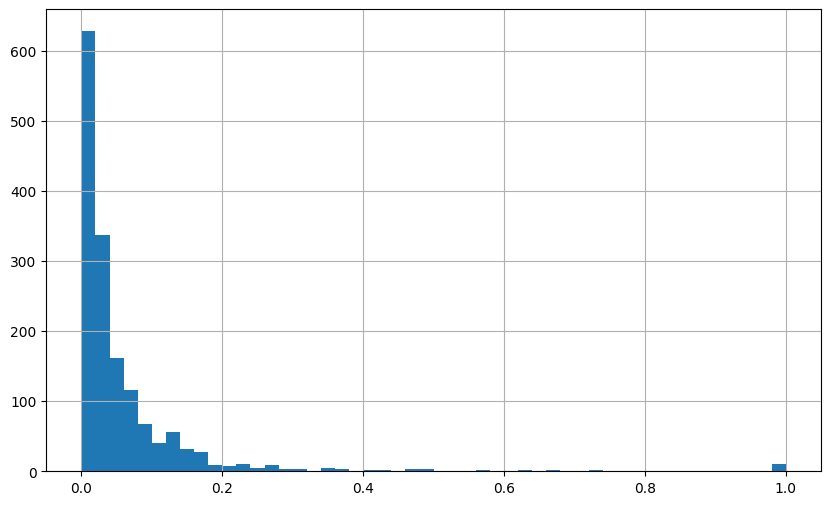

In [13]:
data['popularity'].hist(bins=50, figsize=(10, 6))

In [14]:
import numpy as np
n = 1
np.log10(data["popularity"]*n+1)

,popularity
S.No,
1,0.205570
2,0.277912
3,0.102968
4,0.073332
5,0.018483
...,...
1553,0.064658
1554,0.017089
1555,0.032185


В качестве альтернативного подхода вы можете попробовать дискретизацию признака popularity на основе квантилей (quantile binning), используя функцию qcut() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html). В этом случае вы преобразуете числовой признак popularity в категориальный, для которого в дальнейшем надо будет применить one-hot кодирование.

Теперь давайте обработаем **признак numDeadRelations**.
Посмотрите на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`.

Создайте признак `boolDeadRelations`. Давайте упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

In [15]:
data['boolDeadRelations'] = data['numDeadRelations'] > 0

In [16]:
data[['numDeadRelations', 'boolDeadRelations']].head(10)

,numDeadRelations,boolDeadRelations
S.No,,
1,11,True
2,1,True
3,0,False
4,0,False
5,0,False
6,5,True
7,0,False
8,5,True
9,0,False


Наконец, давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.  

Фактически, в переменной `age` мы заменяем NaN на 0, но одновременно добавляем в модель еще один бинарный признак `age_no_data`, несущий информацию о том, у каких персонажей не был указан возраст:        

In [17]:
data['age_value'] = [0 if np.isnan(x) else x for x in data['age']]
data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]
data[['age_value', 'age_no_data']].head(10)

,age_value,age_no_data
S.No,,
1,0.0,1
2,97.0,0
3,0.0,1
4,23.0,0
5,29.0,0
6,0.0,1
7,26.0,0
8,0.0,1
9,0.0,1


## Задание 1.5. Категориальные признаки с большим количеством категорий

**Признак culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов.

Давайте посмотрим, какие значения принимает данный признак. По умолчанию метод `value_counts()` игнорирует пропуски в данных, поэтому используем этот метод с параметром **dropna** со значением **False** (см. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.value_counts.html)

In [18]:
data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [19]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

**Обратите внимание, что некоторые варианты названий народов встречаются только в тестовых данных, и не встречаются в обучающих данных.** Такая ситуация нередко случается на практике. Поэтому, после обработки обучающих данных и обучения модели важно задать для модели правило, как она должна обрабатывать "незнакомые" категории в категориальных признаках. Например, можно относить объекты с "незнакомой" категорией к некоторой существующей категории или указать формулу расчета для "незнакомой" категории.     

Предложенный вам словарь `cultures_grouped` составлен по всем значениям признака `culture`, встречающимся в тренировочном либо в тестовом датасете. Здесь важно, что все укрупненные категории (ключи/keys словаря `cultures_grouped`) представлены в обоих датасетах, а уникальные для тестового датасета названия народов - это отдельные названия народов внутри укрупненных категорий (значения/values словаря). Поэтому, когда вы будете работать с тестовыми - просто применяйте этот словарь без указания правила обработки "незнакомых" категорий.

Давайте приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

In [20]:
#Довольно просто инвертировать словарь, где ключу соответствует одно значение
#В нашем случае ключу соответствует список значений.
#Ниже показан пример, как можно инвертировать такой словарь

d = {'A': ['a1', 'a2', 'a3'],
     'B': ['b1', 'b2', 'b3', 'b4']}

d_inverted = {}
for k in d.keys():
  for v in d[k]:
      d_inverted.update({v:k})

d_inverted

{'a1': 'A', 'a2': 'A', 'a3': 'A', 'b1': 'B', 'b2': 'B', 'b3': 'B', 'b4': 'B'}

In [21]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}
cultures_grouped_inverted = {}
for k in cultures_grouped.keys():
  for v in cultures_grouped[k]:
      cultures_grouped_inverted.update({v:k})

data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)

Осталось заменить все NaN в созданном столбце на категорию culture_no_data:

In [22]:
data['culture_no_data'] = [1 if pd.isna(x) else 0 for x in data['culture_grouped']]
data[['culture_no_data', 'culture_grouped']]

,culture_no_data,culture_grouped
S.No,,
1,1,NaN
2,0,the Isles and Rivers
3,1,NaN
4,1,NaN
5,0,Dorne
...,...,...
1553,1,NaN
1554,1,NaN
1555,1,NaN


In [23]:
data.loc[data['culture_grouped'].isna(), 'culture_grouped'] = 'culture_no_data'
data['culture_grouped']

,culture_grouped
S.No,
1,culture_no_data
2,the Isles and Rivers
3,culture_no_data
4,culture_no_data
5,Dorne
...,...
1553,culture_no_data
1554,culture_no_data
1555,culture_no_data


**Задание 1.6.** Категориальные признаки в линейных моделях

Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

Если признак принимает одно из двух возможных значений (например, персонаж "появляется" или "не появляется" в 1-й книге), он напрямую кодируется в бинарный признак ("появляется" -> 1, "не появляется" -> 0). Если признак принимает больше двух значений, его можно преобразовать в несколько бинарных при помощи one-hot преобразования. В некоторых случаях бывает полезно объединить некоторые категории, как мы это поступили с признаком *culture*.

Порядковых признаков у нас в задаче нет, поэтому рассматривать их здесь мы не будем.

Для того, чтобы найти все порядковые признаки, посмотрим на количество уникальных значений, которые встречаются в столбцах. Для столбцов с типом object количество уникальных значений мы выводили  при помощи метода `describe()` в задании 1.2.

Чтобы посмотреть количество уникальных значений для всех столбцов, можно воспользоваться методом nunique() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html)

In [24]:
# Количество уникальнх значений в каждом столбце
data.nunique()

,0
name,1557
title,195
male,2
culture,51
dateOfBirth,105
mother,16
father,19
heir,20
house,315
spouse,186


In [25]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
# Код ниже требуется дополнить по аналогии с заданием 1.2.
data.describe(include = 'number').T[['count', 'min', 'max']].assign(N_unique_values = data.nunique())

,count,min,max,N_unique_values
male,1557.0,0.0,1.0,2
dateOfBirth,279.0,-25.0,299.0,105
book1,1557.0,0.0,1.0,2
book2,1557.0,0.0,1.0,2
book3,1557.0,0.0,1.0,2
book4,1557.0,0.0,1.0,2
book5,1557.0,0.0,1.0,2
isAliveMother,18.0,0.0,1.0,2
isAliveFather,22.0,0.0,1.0,2
isAliveHeir,21.0,0.0,1.0,2


Посмотрев на количество уникальных значений мы можем выделить категориальные признаки. Например, `popularity` принимает значения от 0 до 1, но это непрерывный числовой признак. Остальные признаки со значениями от 0 до 1 - принимают только два значения, то есть являются бинарными.

Бинарные признаки без NaN полностью готовы для включения в модель. Некоторые бинарные признаки содержат пропуски, поэтому, если вы захотите включить их в модель, их потребуется обработать.

Для бинарных признаков их связь с зависимой переменной можно прикинуть по таблице корреляций. Для категориальных признаков с количеством значений больше двух (или с двумя значениями и NaN) можно сделать one-hot преобразования и посчитать корреряцию зависимой переменной с набором сгенерированных бинарных признаков.
В качестве альтернативного подхода можно использовать сравнение средних значений зависимой переменной для разных категорий исследуемого признака. Чем сильнее различаются средние значения целевой переменной между категориями, тем вероятнее, что данный признак связан с зависимой переменной.

In [26]:
# попробуйте провести сравнение средних зависимой пременной isAlive для признака isAliveSpouse
# одним из приведенных ниже способов:


# data.groupby('isAliveSpouse', dropna = False)['isAlive'].mean()
pd.pivot_table(data = data, values = 'isAlive', index = 'isAliveSpouse', aggfunc=['mean', 'count'], dropna=False)

,mean,count
,isAlive,isAlive
isAliveSpouse,,
0.0,0.619048,42
1.0,0.753165,158
NaN,0.786293,1357


In [27]:
!ls

drive			  game_of_thrones_train.csv  sample_data
final_submission.csv	  label_encoders.pkl	     submission.csv
game_of_thrones_test.csv  new_submission.csv


**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик. Не забудьте, что потом аналогичным образом вам надо будет преобразовывать тестовый датасет, используя тот же алгоритм кодирования признаков.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [28]:
# Удаление идентификаторов

cols_to_drop = ['name', 'mother', 'father', 'heir', 'spouse', 'culture']
data = data.drop(columns=cols_to_drop, errors='ignore')

In [29]:
# Обработка категоральных признаков и кодировка
binary_cols_with_nan = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']

for col in binary_cols_with_nan:
    data[f'{col}_no_data'] = data[col].isna().astype(int)
    data[col] = data[col].fillna(0)
    
# data[['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']].isnull().sum()

data[['isAliveMother', 'isAliveMother_no_data', 
           'isAliveFather', 'isAliveFather_no_data',
           'isAliveHeir', 'isAliveHeir_no_data',
           'isAliveSpouse', 'isAliveSpouse_no_data']].head(10)

,isAliveMother,isAliveMother_no_data,isAliveFather,isAliveFather_no_data,isAliveHeir,isAliveHeir_no_data,isAliveSpouse,isAliveSpouse_no_data
S.No,,,,,,,,
1,1.0,0,0.0,0,0.0,0,0.0,1
2,0.0,1,0.0,1,0.0,1,1.0,0
3,0.0,1,0.0,1,0.0,1,0.0,1
4,0.0,1,0.0,1,0.0,1,0.0,0
5,0.0,1,0.0,1,0.0,1,1.0,0
6,1.0,0,1.0,0,1.0,0,0.0,1
7,0.0,1,0.0,1,0.0,1,1.0,0
8,1.0,0,1.0,0,1.0,0,0.0,1
9,0.0,1,0.0,1,0.0,1,0.0,1


In [30]:
# Создание признака-индикатора
data['title_no_data'] = data['title'].isna().astype(int)

# Заполнение NaN значениями
data['title'] = data['title'].fillna('Unknown')

# Label Encoding (порядок имеет значение)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['title_encoded'] = le.fit_transform(data['title'])

data['title_encoded'].value_counts().head(10)

,count
title_encoded,
183,840
163,306
125,29
1,21
91,19
162,16
189,15
81,10
74,9


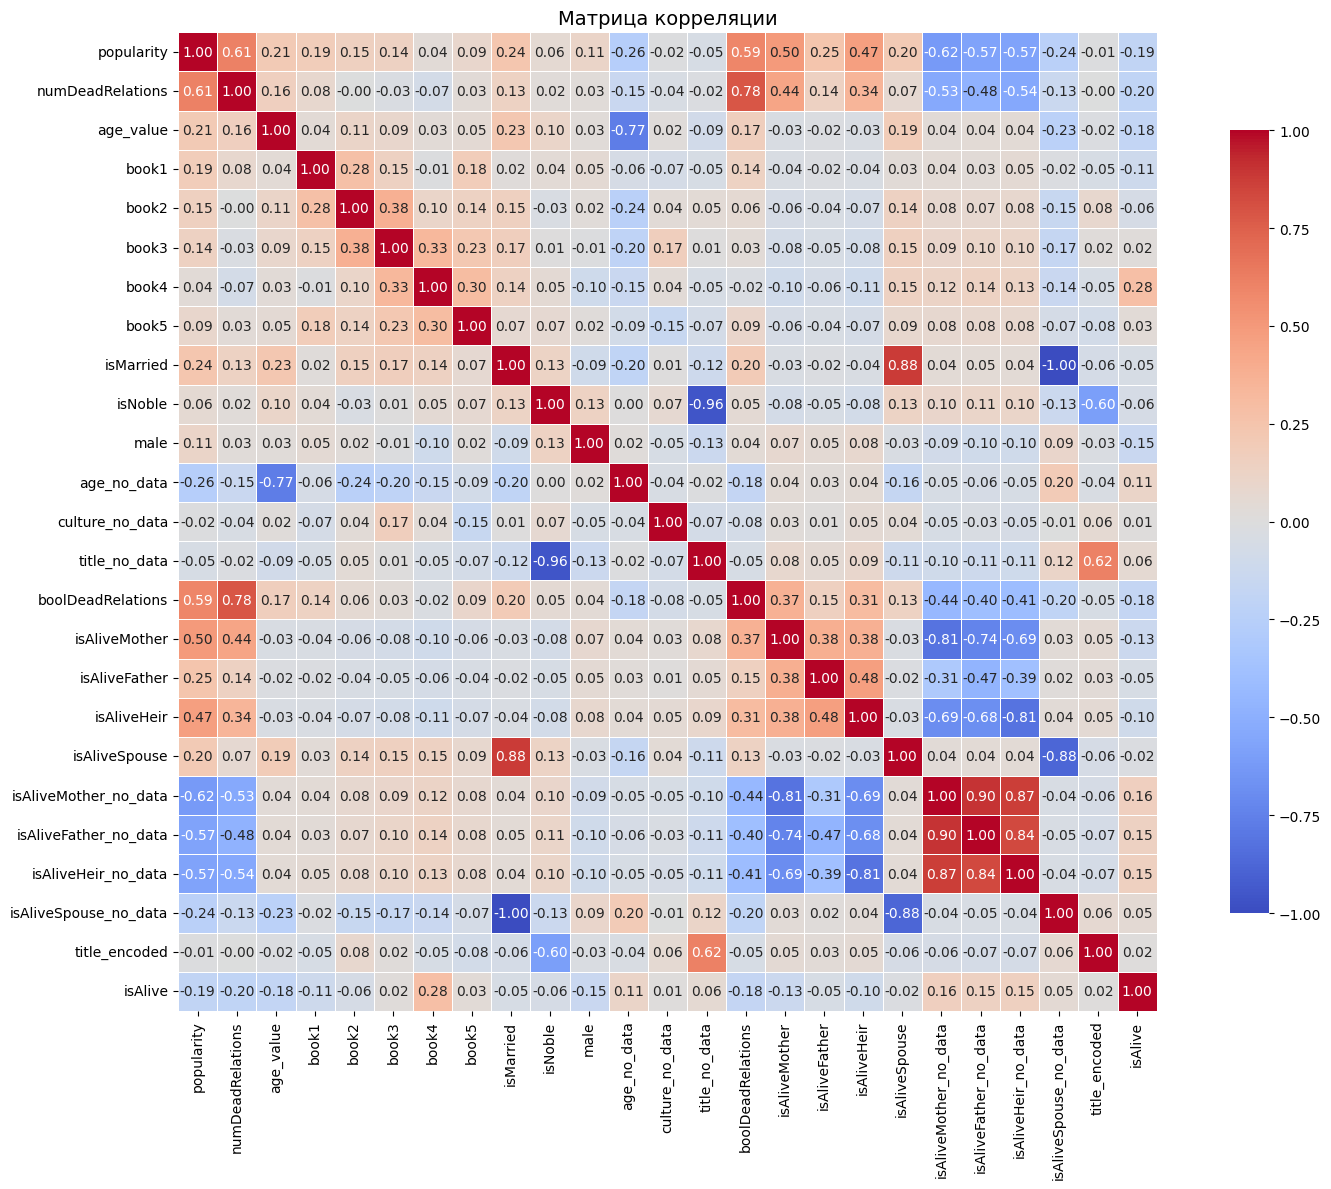

In [31]:
# Корелляционный анализ

import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = [
    'popularity', 'numDeadRelations', 'age_value',
    'book1', 'book2', 'book3', 'book4', 'book5',
    'isMarried', 'isNoble', 'male',
    'age_no_data', 'culture_no_data', 'title_no_data',
    'boolDeadRelations',
    'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
    'isAliveMother_no_data', 'isAliveFather_no_data', 
    'isAliveHeir_no_data', 'isAliveSpouse_no_data',
    'title_encoded'
]

plt.figure(figsize=(16,12))
correlation_matrix = data[numeric_features + ['isAlive']].corr()

sns.heatmap( correlation_matrix,
            annot=True,
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8}
)
plt.title('Матрица корреляции',fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
corr_with_target = data[numeric_features + ['isAlive']].corr()['isAlive'].drop('isAlive').sort_values(ascending=False)
corr_with_target

,isAlive
book4,0.284014
isAliveMother_no_data,0.159302
isAliveHeir_no_data,0.152124
isAliveFather_no_data,0.145771
age_no_data,0.113629
title_no_data,0.056242
isAliveSpouse_no_data,0.049381
book5,0.032531
book3,0.018427
title_encoded,0.015536


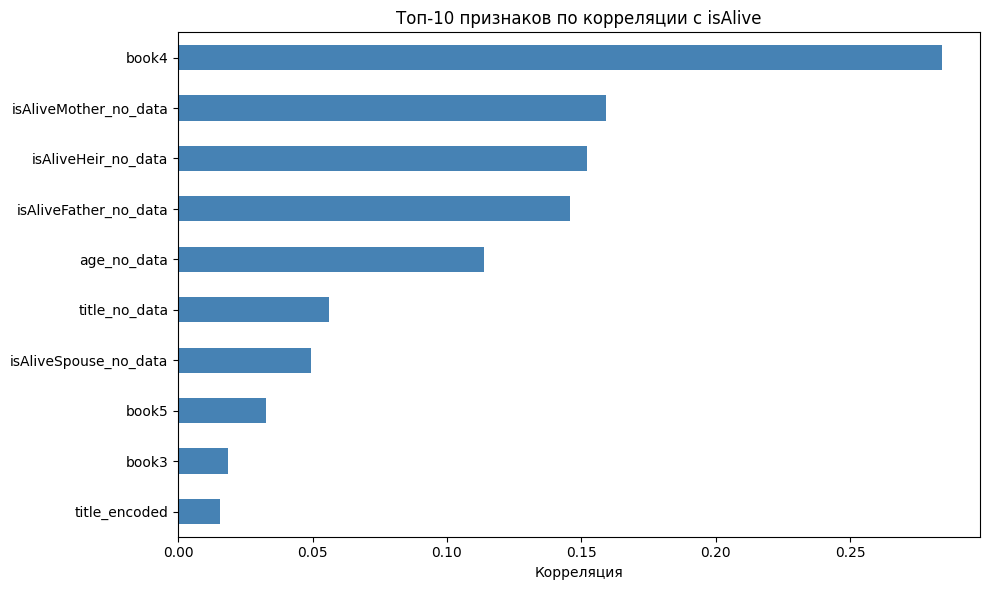

In [33]:
plt.figure(figsize=(10, 6))
corr_with_target.head(10).plot(kind='barh', color='steelblue')
plt.xlabel('Корреляция')
plt.title('Топ-10 признаков по корреляции с isAlive')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [34]:
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((correlation_matrix.columns[i], 
                                   correlation_matrix.columns[j], 
                                   corr_val))

if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"  {pair[0]} и {pair[1]}: {pair[2]:.3f}")
else:
    print("  Высокой корреляции между признаками не обнаружено")

  numDeadRelations и boolDeadRelations: 0.782
  age_value и age_no_data: -0.772
  isMarried и isAliveSpouse: 0.875
  isMarried и isAliveSpouse_no_data: -1.000
  isNoble и title_no_data: -0.958
  isAliveMother и isAliveMother_no_data: -0.815
  isAliveMother и isAliveFather_no_data: -0.736
  isAliveHeir и isAliveHeir_no_data: -0.815
  isAliveSpouse и isAliveSpouse_no_data: -0.875
  isAliveMother_no_data и isAliveFather_no_data: 0.903
  isAliveMother_no_data и isAliveHeir_no_data: 0.873
  isAliveFather_no_data и isAliveHeir_no_data: 0.835


In [35]:
print(f"• Сильнее всего с isAlive коррелирует: {corr_with_target.index[0]} ({corr_with_target.values[0]:.3f})")
print(f"• Отрицательная корреляция: {corr_with_target.index[-1]} ({corr_with_target.values[-1]:.3f})")

• Сильнее всего с isAlive коррелирует: book4 (0.284)
• Отрицательная корреляция: numDeadRelations (-0.199)


In [36]:
object_cols = data.select_dtypes(include=['object']).columns.tolist()
print("Столбцы с текстовым типом данных:")
print(object_cols)

Столбцы с текстовым типом данных:
['title', 'house', 'culture_grouped']


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Словарь для хранения кодировщика

le_dict = {}  

# Обработка бинарных признаков с NaN

binary_cols_with_nan = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']

for col in binary_cols_with_nan:
    if col in data.columns:
        data[f'{col}_no_data'] = data[col].isna().astype(int)
        data[col] = data[col].fillna(0)

print(" Бинарные признаки обработаны")

# Обработка title

if 'title' in data.columns:
    # Создаем признак-индикатор пропуска
    data['title_no_data'] = data['title'].isna().astype(int)
    
    # Заполняем NaN
    data['title'] = data['title'].fillna('unknown')
    
    # Label Encoding
    le_title = LabelEncoder()
    data['title_encoded'] = le_title.fit_transform(data['title'])
    le_dict['title'] = le_title  # <--- СОХРАНЯЕМ В СЛОВАРЬ
    
    # Удаляем исходный title
    data = data.drop(columns=['title'])
    print("title обработан")
else:
    print("Колонка 'title' отсутствует в данных")

# Обработка culture_grouped (One-Hot Encoding)

if 'culture_grouped' in data.columns:
    # One-Hot кодирование для culture_grouped
    culture_dummies = pd.get_dummies(data['culture_grouped'], prefix='culture')
    data = pd.concat([data, culture_dummies], axis=1)
    
    # Сохраняем названия One-Hot колонок для теста
    le_dict['culture_dummy_columns'] = culture_dummies.columns.tolist()  # <--- СОХРАНЯЕМ
    
    # Удаляем исходный culture_grouped
    data = data.drop(columns=['culture_grouped'])
    
    print(f"culture_grouped закодирован One-Hot, создано {culture_dummies.shape[1]} признаков")
else:
    print("Колонка 'culture_grouped' отсутствует в данных")

# Обработка house (частотное кодирование)

if 'house' in data.columns:
    data['house_no_data'] = data['house'].isna().astype(int)
    
    data['house'] = data['house'].fillna('unknown')
    
    # Частотное кодирование
    house_freq = data['house'].value_counts(normalize=True)
    data['house_encoded'] = data['house'].map(house_freq)
    
    # Сохранение частоты для теста
    le_dict['house_freq'] = house_freq.to_dict()
    
    data = data.drop(columns=['house'])
    
    print("house закодирован частотным кодированием")
else:
    print("Колонка 'house' отсутствует в данных")

# Обработка dateOfBirth

if 'dateOfBirth' in data.columns:
    data['dateOfBirth_no_data'] = data['dateOfBirth'].isna().astype(int)
    data['dateOfBirth'] = data['dateOfBirth'].fillna(0)
    print("dateOfBirth обработан")
else:
    print("Колонка 'dateOfBirth' отсутствует в данных")

# Обработка возраста

if 'age' in data.columns:
    data['age_value'] = data['age'].fillna(0)
    data['age_no_data'] = data['age'].isna().astype(int)
    data = data.drop(columns=['age'])
    print("age обработан (созданы age_value и age_no_data)")
else:
    print("Колонка 'age' отсутствует в данных")


# Создание boolDeadRelations

if 'numDeadRelations' in data.columns:
    data['boolDeadRelations'] = data['numDeadRelations'] > 0
    # Оставляем boolDeadRelations, удаляем numDeadRelations
    data = data.drop(columns=['numDeadRelations'])
    print(" boolDeadRelations создан")
else:
    print("Колонка 'numDeadRelations' отсутствует в данных")

if 'cultures_grouped_inverted' in dir():
    le_dict['cultures_grouped_inverted'] = cultures_grouped_inverted
    print("cultures_grouped_inverted сохранен")
else:
    print("cultures_grouped_inverted не найден")


 Бинарные признаки обработаны
Колонка 'title' отсутствует в данных
Колонка 'culture_grouped' отсутствует в данных
Колонка 'house' отсутствует в данных
dateOfBirth обработан
Колонка 'age' отсутствует в данных
 Колонка 'numDeadRelations' отсутствует в данных
 cultures_grouped_inverted сохранен


In [70]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. СОЗДАЕМ КОМПОЗИТНЫЕ ПРИЗНАКИ (вместо удаления)

# Семейный признак: сколько живых родственников
data['alive_relatives'] = (
    data['isAliveMother'].fillna(0) + 
    data['isAliveFather'].fillna(0) + 
    data['isAliveHeir'].fillna(0) + 
    data['isAliveSpouse'].fillna(0)
)

# Семейный признак: сколько данных о родственниках есть
data['relatives_data_available'] = (
    (1 - data['isAliveMother_no_data']) +
    (1 - data['isAliveFather_no_data']) +
    (1 - data['isAliveHeir_no_data']) +
    (1 - data['isAliveSpouse_no_data'])
)

# Признак: общая популярность в книгах
data['total_book_appearances'] = data[['book1', 'book2', 'book3', 'book4', 'book5']].sum(axis=1)

# Признак: сколько книг, в которых появлялся персонаж
data['books_count'] = (data[['book1', 'book2', 'book3', 'book4', 'book5']] > 0).sum(axis=1)

print(" Композитные признаки созданы")

# 2. ВЫБИРАЕМ ПРИЗНАКИ ДЛЯ МОДЕЛИ (сбалансированный подход)

features = [
    # Демография
    'male', 'isMarried', 'isNoble',
    
    # Книги (используем суммарные признаки вместо отдельных)
    'total_book_appearances', 'books_count',
    # Можно оставить и отдельные книги, если хотите
    'book4',  # book4 показал высокую корреляцию с isAlive
    
    # Популярность и смерть
    'popularity', 'boolDeadRelations',
    
    # Возраст (оба!)
    'age_value', 'age_no_data',
    
    # Дата рождения
    'dateOfBirth', 'dateOfBirth_no_data',
    
    # Титул
    'title_encoded', 'title_no_data',
    
    # Дом
    'house_encoded', 'house_no_data',
    
    # КОМПОЗИТНЫЕ СЕМЕЙНЫЕ ПРИЗНАКИ (вместо 8 отдельных)
    'alive_relatives', 'relatives_data_available',
    
    # МОЖНО ОСТАВИТЬ И ОТДЕЛЬНЫЕ, если хотите
    # 'isAliveMother', 'isAliveMother_no_data',
    # 'isAliveFather', 'isAliveFather_no_data',
    # 'isAliveHeir', 'isAliveHeir_no_data',
    # 'isAliveSpouse', 'isAliveSpouse_no_data',
]

# Добавляем One-Hot культуры
culture_cols = [col for col in data.columns if col.startswith('culture_')]
features.extend(culture_cols)

 Композитные признаки созданы


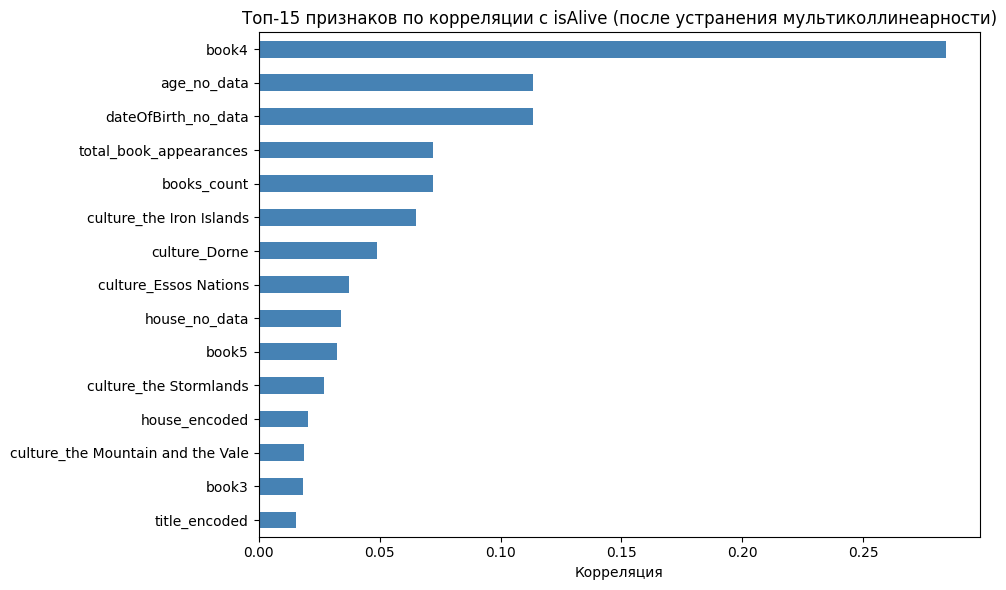

In [39]:
# Корреляция с isAlive после удаления высококоррелирующих признаков

remaining_features = [col for col in data.columns if col != 'isAlive']
corr_after = data[remaining_features + ['isAlive']].corr()['isAlive'].drop('isAlive').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
corr_after.head(15).plot(kind='barh', color='steelblue')
plt.xlabel('Корреляция')
plt.title('Топ-15 признаков по корреляции с isAlive (после устранения мультиколлинеарности)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

In [40]:
binary_features = ['male', 'isMarried', 'isNoble', 'boolDeadRelations',
                   'age_no_data', 'culture_no_data', 'title_no_data',
                   'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']

print("1. Анализ бинарных признаков (среднее значение isAlive по категориям):")

for col in binary_features:
    if col in data.columns:
        mean_by_category = data.groupby(col, dropna=False)['isAlive'].mean()
        print(f"\n{col}:")
        print(mean_by_category)

print("2. Анализ категориальных признаков:")

# culture_grouped (уже закодирован, но можно посмотреть распределение)
if 'culture_grouped' in data.columns:
    print("\nculture_grouped (среднее isAlive по группам):")
    culture_impact = data.groupby('culture_grouped')['isAlive'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print(culture_impact)

# title (можно посмотреть топ-10 титулов по выживаемости)
if 'title' in data.columns:
    print("\ntitle (топ-10 титулов по выживаемости):")
    title_impact = data.groupby('title')['isAlive'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10)
    print(title_impact)

1. Анализ бинарных признаков (среднее значение isAlive по категориям):

male:
male
0    0.852433
1    0.727174
Name: isAlive, dtype: float64

isMarried:
isMarried
0    0.786293
1    0.725000
Name: isAlive, dtype: float64

isNoble:
isNoble
0    0.800687
1    0.750000
Name: isAlive, dtype: float64

boolDeadRelations:
boolDeadRelations
False    0.794355
True     0.434783
Name: isAlive, dtype: float64

age_no_data:
age_no_data
0    0.677419
1    0.800469
Name: isAlive, dtype: float64

culture_no_data:
culture_no_data
0    0.772541
1    0.781104
Name: isAlive, dtype: float64

title_no_data:
title_no_data
0    0.77842
Name: isAlive, dtype: float64

isAliveMother:
isAliveMother
0.0    0.783172
1.0    0.166667
Name: isAlive, dtype: float64

isAliveFather:
isAliveFather
0.0    0.779639
1.0    0.400000
Name: isAlive, dtype: float64

isAliveHeir:
isAliveHeir
0.0    0.782242
1.0    0.357143
Name: isAlive, dtype: float64

isAliveSpouse:
isAliveSpouse
0.0    0.781272
1.0    0.753165
Name: isAlive, d

3. Анализ количественных признаков:


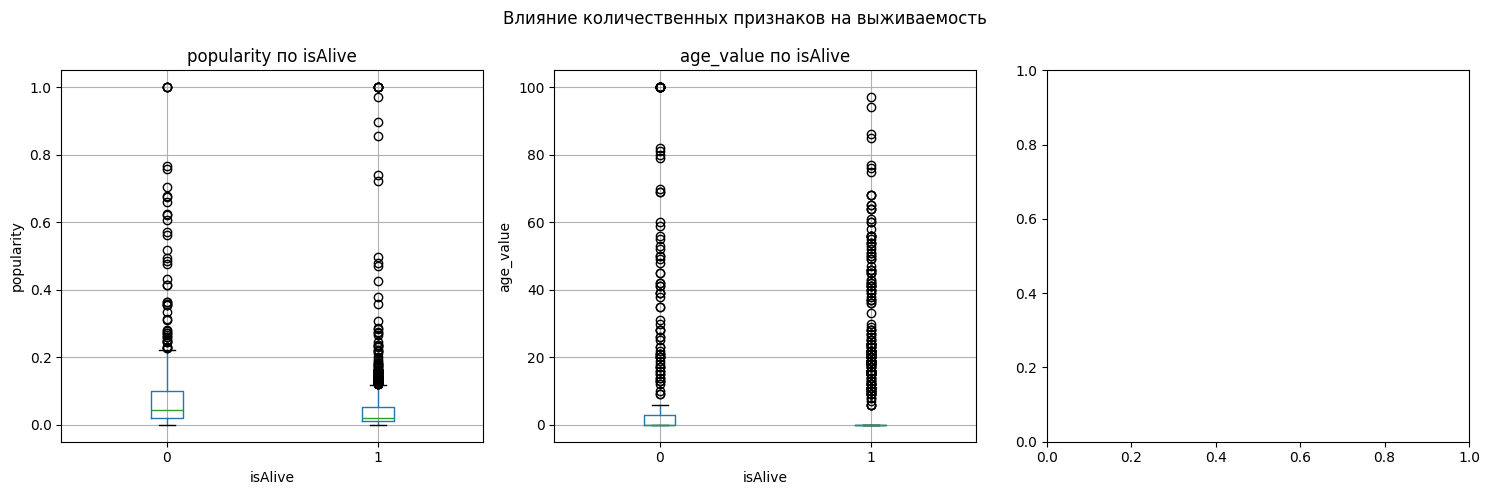

In [41]:
print("3. Анализ количественных признаков:")

numeric_features_analysis = ['popularity', 'age_value']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feat in enumerate(numeric_features_analysis):
    # Боксплоты по isAlive
    data.boxplot(column=feat, by='isAlive', ax=axes[i])
    axes[i].set_title(f'{feat} по isAlive')
    axes[i].set_xlabel('isAlive')
    axes[i].set_ylabel(feat)

plt.suptitle('Влияние количественных признаков на выживаемость')
plt.tight_layout()
plt.show()

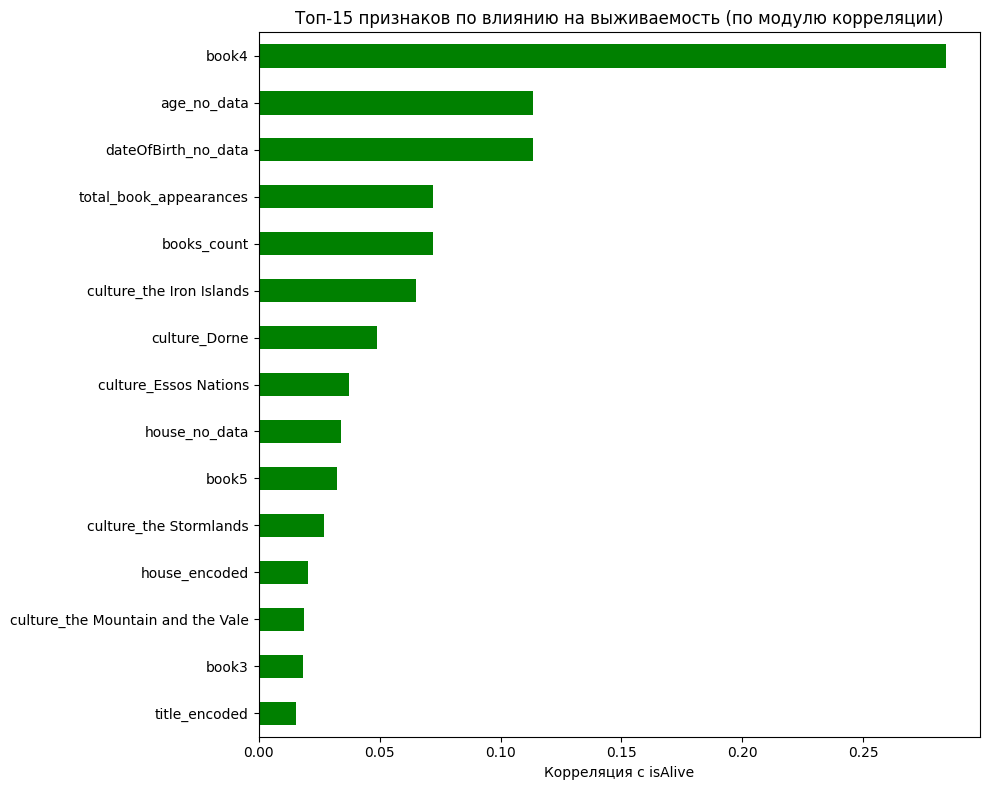

In [42]:
corr_with_target_clean = data.corr()['isAlive'].drop('isAlive').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
top_features = corr_with_target_clean.head(15)
colors = ['green' if x > 0 else 'red' for x in top_features.values]
top_features.plot(kind='barh', color=colors)
plt.xlabel('Корреляция с isAlive')
plt.title('Топ-15 признаков по влиянию на выживаемость (по модулю корреляции)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, которые вы отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [43]:
X = data.drop(columns='isAlive', errors='ignore')
y = data['isAlive']


print(f"\nПризнаки для модели ({len(X.columns)}):")
print(X.columns.tolist())
print(f"\nПропусков в X: {X.isnull().sum().sum()}")
print(f"Пропусков в y: {y.isnull().sum()}")


Признаки для модели (43):
['male', 'dateOfBirth', 'book1', 'book2', 'book3', 'book4', 'book5', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse', 'isMarried', 'isNoble', 'popularity', 'boolDeadRelations', 'age_value', 'age_no_data', 'culture_no_data', 'isAliveMother_no_data', 'isAliveFather_no_data', 'isAliveHeir_no_data', 'isAliveSpouse_no_data', 'title_no_data', 'title_encoded', 'culture_Dorne', 'culture_Essos Nations', 'culture_Old Nations', 'culture_Other Nations', 'culture_culture_no_data', 'culture_the Iron Islands', 'culture_the Isles and Rivers', 'culture_the Mountain and the Vale', 'culture_the North', 'culture_the Reach', 'culture_the Rock', 'culture_the Stormlands', 'house_no_data', 'house_encoded', 'dateOfBirth_no_data', 'alive_relatives', 'relatives_data_available', 'total_book_appearances', 'books_count']

Пропусков в X: 0
Пропусков в y: 0


**Задание 1.10.** Разделите датасет обучащую и валидационные части (train и val) при помощи функции `train_test_split` (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [ ]:
from sklearn.model_selection import train_test_split
import joblib

from sklearn.impute import SimpleImputer


# Разделение признаки по типам
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Импьютер для числовых
num_imputer = SimpleImputer(strategy='median')
X_numeric = num_imputer.fit_transform(X[numeric_cols])

# Импьютер для категориальных
if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_categorical = cat_imputer.fit_transform(X[categorical_cols])
    X_processed = np.hstack([X_numeric, X_categorical])
else:
    X_processed = X_numeric

X_processed = pd.DataFrame(X_processed, columns=numeric_cols.tolist() + categorical_cols.tolist())

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")

# Сохранение кодировщиков для тестового датасета
joblib.dump(le_dict, 'label_encoders.pkl')

X_train: (1245, 43)
X_val:   (312, 43)
y_train: (1245,)
y_val:   (312,)


['label_encoders.pkl']

In [45]:
!ls

drive			  game_of_thrones_train.csv  sample_data
final_submission.csv	  label_encoders.pkl	     submission.csv
game_of_thrones_test.csv  new_submission.csv


## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.**


Вы можете работать с одной из предложенных моделей из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier

Однако в этом домашнем задании мы предлагаем выбрать и поработать с моделью `LogisticRegression`.

In [46]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Шаг 1. Создание модели (Pipeline)
model = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=5000,      # еще больше итераций
                       tol=1e-4,           # менее строгий критерий остановки
                       random_state=42,
                       class_weight='balanced')
)

# Шаг 2. Обучение модели
model.fit(X_train, y_train)

# Шаг 3. Предсказание на валидационных данных
y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]


# Получаем саму модель логистической регрессии из Pipeline
logreg_model = model.named_steps['logisticregression']


print(f"Количество признаков: {X_train.shape[1]}")
print(f"Количество итераций обучения: {logreg_model.n_iter_[0]}")
print(f"Intercept: {logreg_model.intercept_[0]:.4f}")
print(f"\nКоэффициенты модели (первые 10):")
for i, coef in enumerate(logreg_model.coef_[0][:10]):
    print(f"  {X_train.columns[i] if hasattr(X_train, 'columns') else f'feature_{i}'}: {coef:.4f}")

# Оценка качества

print(f"Accuracy:  {accuracy_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Умер (0)', 'Выжил (1)']))

Количество признаков: 43
Количество итераций обучения: 35
Intercept: 0.3165

Коэффициенты модели (первые 10):
  male: -0.2163
  dateOfBirth: 3.0441
  book1: -0.1726
  book2: -0.3075
  book3: -0.1819
  book4: 0.7800
  book5: -0.1153
  isAliveMother: -0.1867
  isAliveFather: -0.0215
  isAliveHeir: -0.0446
Accuracy:  0.6891
ROC-AUC:   0.7470

Classification Report:
              precision    recall  f1-score   support

    Умер (0)       0.39      0.70      0.50        69
   Выжил (1)       0.89      0.69      0.77       243

    accuracy                           0.69       312
   macro avg       0.64      0.69      0.64       312
weighted avg       0.78      0.69      0.71       312



## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [48]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [55]:
!pip install xgboost

In [56]:
from xgboost import XGBClassifier
import time


xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)


# Оценка на валидации
y_pred_xgb = xgb_model.predict(X_val)
y_pred_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

print("\n" + "="*60)
print("XGBOOST РЕЗУЛЬТАТЫ")
print("="*60)
print(f"Accuracy: {accuracy_score(y_val, y_pred_xgb):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_val, y_pred_proba_xgb):.4f}")

# Сохраняем лучшую модель
best_model = xgb_model

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBOOST РЕЗУЛЬТАТЫ
Accuracy: 0.8301
ROC-AUC:  0.8665


Возможно, вы решите вернуться на несколько шагов и попробовать другие варианты преобразования и подбора признаков в модель. **Выберите** лучшую модель.

In [57]:
data_test = pd.read_csv('/content/game_of_thrones_test.csv', index_col='S.No')

if 1685 in data_test.index:
    data_test.loc[1685, 'dateOfBirth'] = 278.0
    data_test.loc[1685, 'age'] = 0.0

if 1869 in data_test.index:
    data_test.loc[1869, 'dateOfBirth'] = 299.0
    data_test.loc[1869, 'age'] = 0.0

In [ ]:
# ПОДГОТОВКА ТЕСТОВЫХ ДАННЫХ


cols_to_drop = ['name', 'mother', 'father', 'heir', 'spouse']
data_test = data_test.drop(columns=cols_to_drop, errors='ignore')
print(f"После удаления идентификаторов: {data_test.shape}")

binary_cols_with_nan = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']

for col in binary_cols_with_nan:
    if col in data_test.columns:
        data_test[f'{col}_no_data'] = data_test[col].isna().astype(int)
        data_test[col] = data_test[col].fillna(0)

print("Бинарные признаки обработаны")

if 'title' in data_test.columns:
    data_test['title_no_data'] = data_test['title'].isna().astype(int)
    data_test['title'] = data_test['title'].fillna('unknown')
    
    if 'le_title' in dir() and le_title is not None:
        data_test['title_encoded'] = data_test['title'].apply(
            lambda x: le_title.transform([x])[0] if x in le_title.classes_ else -1
        )
    else:
        print("le_title не найден, создаем новый")
        le_title = LabelEncoder()
        data_test['title_encoded'] = le_title.fit_transform(data_test['title'])
    
    data_test = data_test.drop(columns=['title'])
    print("title обработан")
else:
    print("Колонка 'title' отсутствует в тестовых данных")

if 'culture' in data_test.columns and 'cultures_grouped_inverted' in dir():
    data_test['culture_grouped'] = data_test['culture'].str.lower().map(cultures_grouped_inverted)
    data_test['culture_grouped'] = data_test['culture_grouped'].fillna('culture_no_data')
    data_test = data_test.drop(columns=['culture'])
    
    culture_dummies_test = pd.get_dummies(data_test['culture_grouped'], prefix='culture')
    
    if 'culture_dummies' in dir():
        for col in culture_dummies.columns:
            if col not in culture_dummies_test.columns:
                culture_dummies_test[col] = 0
        culture_dummies_test = culture_dummies_test[culture_dummies.columns]
    
    data_test = pd.concat([data_test, culture_dummies_test], axis=1)
    data_test = data_test.drop(columns=['culture_grouped'])
    print(f"culture_grouped обработан, создано {culture_dummies_test.shape[1]} признаков")
else:
    print("culture не обработан")

if 'house' in data_test.columns:
    data_test['house_no_data'] = data_test['house'].isna().astype(int)
    data_test['house'] = data_test['house'].fillna('unknown')
    
    if 'house_freq' in dir():
        data_test['house_encoded'] = data_test['house'].map(house_freq).fillna(0)
    else:
        house_freq_test = data_test['house'].value_counts(normalize=True)
        data_test['house_encoded'] = data_test['house'].map(house_freq_test).fillna(0)
    
    data_test = data_test.drop(columns=['house'])
    print("house обработан")

if 'dateOfBirth' in data_test.columns:
    data_test['dateOfBirth_no_data'] = data_test['dateOfBirth'].isna().astype(int)
    data_test['dateOfBirth'] = data_test['dateOfBirth'].fillna(0)
print("dateOfBirth обработан")

if 'age' in data_test.columns:
    data_test['age_value'] = data_test['age'].fillna(0)
    data_test['age_no_data'] = data_test['age'].isna().astype(int)
    data_test = data_test.drop(columns=['age'])
print("age обработан")

if 'numDeadRelations' in data_test.columns:
    data_test['boolDeadRelations'] = data_test['numDeadRelations'] > 0
    data_test = data_test.drop(columns=['numDeadRelations'])
print("boolDeadRelations создан")



После удаления идентификаторов: (389, 43)
Бинарные признаки обработаны
Колонка 'title' отсутствует в тестовых данных
culture не обработан
dateOfBirth обработан
age обработан
boolDeadRelations создан


In [52]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF


Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 7.75MB/s]


In [66]:
# Создание X_test
# Перенос колонок, которые есть в X_train
missing_cols = []
X_test = pd.DataFrame(index=data_test.index)

# Копируем колонки, которые есть в data_test
for col in X_train.columns:
    if col in data_test.columns:
        X_test[col] = data_test[col]
    else:
        # Если колонки нет, создаем ее с нулями (для колонок, которые были удалены при мультикорреляции)
        missing_cols.append(col)
        X_test[col] = 0

missing_in_test = set(X_train.columns) - set(X_test.columns)
if missing_in_test:
    print(f" В тесте отсутствуют колонки: {missing_in_test}")
    for col in missing_in_test:
        X_test[col] = 0

X_test = X_test[X_train.columns]

print(f"X_test готов. Размер: {X_test.shape}")
print(f"Колонки в X_test: {X_test.columns.tolist()[:5]}...")

y_test_pred = best_model.predict(X_test)

submission = pd.read_csv("/content/submission.csv", index_col='S.No')
submission['isAlive'] = y_test_pred
submission.to_csv("/content/final_submission_1.csv", index=True)



X_test готов. Размер: (389, 43)
Колонки в X_test: ['male', 'dateOfBirth', 'book1', 'book2', 'book3']...


In [67]:
!cp /content/final_submission_1.csv /content/drive/MyDrive